In [ ]:
import os
import sys
import torch
import numpy as np
import torch.nn as nn
from pathlib import Path
import torchvision.datasets as Datasets
import pandas as pd
import pickle
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import torch
from monai.networks.nets import UNet
from monai.networks.layers import Norm
from monai import transforms
from torch.utils.data import Dataset
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
import random
import numpy as np
from skimage.transform import rotate
from skimage.util import random_noise
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchmetrics import MeanSquaredError, R2Score 
from skimage import measure 
from torch.utils.data import DataLoader
from torch.nn.utils import clip_grad_norm_


sys.path.append('/home/ee577/project')

pkg_path = str(Path(os.path.abspath('')).parent.absolute())
sys.path.insert(0, pkg_path)

data_path='/home/ee577/project'+'/results/'

from src import *

# Load config file
config = global_config.config
device = torch.device(config.device) 


2025-03-10 20:26:39.178571: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1741663599.191006  521184 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1741663599.194689  521184 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-10 20:26:39.209256: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
direct_pairs='/home/ee577/project/results/DTI_AD_NC_paired_data.pkl'

with open(direct_pairs, 'rb') as f:
    X, y = pickle.load(f)

print(f"Loaded X shape: {X.shape}")
print(f"Loaded y shape: {y.shape}")


Loaded X shape: (499, 74, 98, 86)
Loaded y shape: (499, 55)


In [22]:


def create_segmentation_mask(image, threshold=0.1):
    """
    Create a binary segmentation mask for the image based on a threshold.
    
    Args:
        image (numpy.array or torch.Tensor): The input image to segment.
        threshold (float): The intensity threshold to classify pixels as part of the region of interest.
    
    Returns:
        mask (numpy.array or torch.Tensor): The binary segmentation mask.
    """
    # Convert to numpy array if it's a tensor
    if isinstance(image, torch.Tensor):
        image = image.cpu().detach().numpy()

    mask = image > threshold
    
    labeled_mask = measure.label(mask, connectivity=2)  
    mask = labeled_mask > 0  

    return torch.tensor(mask, dtype=torch.float32)

segmentation_masks = []

for i in range(X.shape[0]):  
    image = X[i, :, :, :]  
    mask = create_segmentation_mask(image, threshold=0.1)
    segmentation_masks.append(mask)

segmentation_masks = np.stack(segmentation_masks)
print(f"Segmentation Masks Shape: {segmentation_masks.shape}")


Segmentation Masks Shape: (499, 74, 98, 86)


In [ ]:


# Ensure X and segmentation_masks are combined and split together
X_train, X_temp, segmentation_masks_train, segmentation_masks_temp, y_train, y_temp = train_test_split(
    X, segmentation_masks, y, test_size=0.2, random_state=1)

# Split the temporary set into validation and test (70% validation, 30% test)
X_val, X_test, segmentation_masks_val, segmentation_masks_test, y_val, y_test = train_test_split(
    X_temp, segmentation_masks_temp, y_temp, test_size=0.7, random_state=1)

# Normalize target variables y_train, y_val, y_test
scaler = StandardScaler()
y_train = scaler.fit_transform(y_train)
y_val = scaler.transform(y_val)
y_test = scaler.transform(y_test)

# Print the shapes of the resulting splits
print(f"Training set: X_train={X_train.shape}, y_train={y_train.shape}, segmentation_masks_train={segmentation_masks_train.shape}")
print(f"Validation set: X_val={X_val.shape}, y_val={y_val.shape}, segmentation_masks_val={segmentation_masks_val.shape}")
print(f"Test set: X_test={X_test.shape}, y_test={y_test.shape}, segmentation_masks_test={segmentation_masks_test.shape}")


Training set: X_train=(399, 74, 98, 86), y_train=(399, 55), segmentation_masks_train=(399, 74, 98, 86)
Validation set: X_val=(30, 74, 98, 86), y_val=(30, 55), segmentation_masks_val=(30, 74, 98, 86)
Test set: X_test=(70, 74, 98, 86), y_test=(70, 55), segmentation_masks_test=(70, 74, 98, 86)


In [5]:

def random_flip(image):
    """
    Randomly flips the image horizontally or vertically.
    
    Args:
    - image (numpy.ndarray or torch.Tensor): Input image, can be a numpy array or torch tensor.
    
    Returns:
    - torch.Tensor: Randomly flipped image.
    """
    if isinstance(image, np.ndarray):
        image = torch.tensor(image)
    
    if image.dim() == 3:
        image = image.unsqueeze(0)
    
    # (batch_size, channels, height, width)
    if image.dim() == 4:
        # Flip horizontally (along the width axis)
        if random.random() < 0.5:
            image = image.flip(3)  
        
        # Flip vertically (along the height axis)
        if random.random() < 0.5:
            image = image.flip(2)  
    else:
        raise ValueError(f"Expected image to have 3 or 4 dimensions, but got {image.dim()} dimensions.")
    
    # If we added a batch dimension earlier (for single image), remove it now
    if image.dim() == 4:
        image = image.squeeze(0)
    
    return image

def add_random_noise(image, noise_factor=0.05):
    """
    Adds random noise to the image.
    """
    noise = np.random.normal(0, noise_factor, image.shape)
    return image + noise


In [6]:
class CustomDataset(Dataset):
    def __init__(self, images, labels, masks=None, transform=None):
        """
        Args:
            images (numpy array or torch tensor): 4D tensor with shape (N, D, H, W), where N is the number of samples
            labels (numpy array or torch tensor): 2D tensor with shape (N, num_features), where N is the number of samples
            masks (numpy array or torch tensor, optional): 4D tensor with shape (N, D, H, W), where N is the number of samples
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.images = images
        self.labels = labels
        self.masks = masks  # Optional masks for segmentation
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        # Get the segmentation mask for this sample if provided
        if self.masks is not None:
            mask = self.masks[idx]
        else:
            mask = None

        # Convert to torch tensor if necessary
        if isinstance(image, np.ndarray):
            image = torch.tensor(image, dtype=torch.float32)

        label = torch.tensor(label, dtype=torch.float32)

        # If the image is 3D (D, H, W), add channel dimension (1, D, H, W)
        if image.ndimension() == 3:  # (D, H, W)
            image = image.unsqueeze(0)  # Add channel dimension (Shape becomes: (1, D, H, W))

        # Apply transformation to the image if specified
        if self.transform:
            image = self.transform(image)

        # Return the image, label, and mask (if available)
        if mask is not None:
            if isinstance(mask, np.ndarray):
                mask = torch.tensor(mask, dtype=torch.float32)
                if mask.ndimension() == 3:  # (D, H, W)
                    mask = mask.unsqueeze(0)
                return {'image': image, 'label': label, 'mask': mask}
        else:
            return {'image': image, 'label': label}


In [7]:
class UNet3DRegression(nn.Module):
    def __init__(self, in_channels, out_channels, weights,segmentation_weight=0.8, l1_lambda=1e-10):
        super(UNet3DRegression, self).__init__()

        # Initialize UNet with 3D structure
        self.unet = UNet(
            spatial_dims=3,
            in_channels=in_channels,
            out_channels=out_channels,
            channels=(16, 32, 64, 128),
            strides=(2, 2, 2),
            kernel_size=3,
            up_kernel_size=3,
            num_res_units=2,
            act='PReLU',
            norm='INSTANCE',
            dropout=0.1,
        )

        # Initialize regression layer as None initially
        self.regression_layer = nn.Identity()
        sum_weights=sum(weights)
        self.weights = weights/sum_weights
        self.dropout = nn.Dropout3d(p=0.3)
        self.l1_lambda = l1_lambda
        self.segmentation_weight=segmentation_weight
        self.segmentation_head = nn.Conv3d(out_channels, 1, kernel_size=1)

    def forward(self, x):
        if x.ndimension() == 4:  # Shape: (channels, depth, height, width)
            x = x.unsqueeze(0)
        
        _, _, depth, height, width = x.size()
        if depth % 16 != 0 or height % 16 != 0 or width % 16 != 0:
            new_depth = (depth // 16 + 1) * 16
            new_height = (height // 16 + 1) * 16
            new_width = (width // 16 + 1) * 16
            x = F.interpolate(x, size=(new_depth, new_height, new_width), mode='trilinear', align_corners=True)

        x = self.unet(x)
        x = self.dropout(x)
        segmentation_output = self.segmentation_head(x)

        # Apply global average pooling to reduce the spatial dimensions
        # The output shape will be (batch_size, channels, 1, 1, 1)
        x = F.adaptive_avg_pool3d(x, (1, 1, 1))  # Global average pooling
        x = x.view(x.size(0), -1)  # Flatten to [batch_size, channels]

        # Initialize regression_layer with the correct output size dynamically during the forward pass
        if isinstance(self.regression_layer, nn.Identity):
            self.regression_layer = nn.Linear(x.size(1), 55)  # Adjust output to 55

        regression_output = self.regression_layer(x)  # Apply regression layer (55 output features)

        # print(f"Regression tensor size: {regression_output.size()}")
        return {'segmentation_output': segmentation_output, 'regression_output': regression_output}
    
    def weighted_mse_loss(self, segmentation_output, regression_output, target_segmentation, target_regression):
        """
        Combines the segmentation loss and regression loss into a single loss function.
        Args:
            segmentation_output (Tensor): The output of the model for segmentation.
            regression_output (Tensor): The output of the model for regression.
            target_segmentation (Tensor): The ground truth segmentation.
            target_regression (Tensor): The ground truth regression labels.
        """
        
        # Resize the segmentation output to match the size of the target segmentation
        target_size = target_segmentation.shape[2:]  # [74, 98, 86]
        segmentation_output = F.interpolate(segmentation_output, size=target_size, mode='trilinear', align_corners=False)
        # Calculate the binary cross-entropy loss for segmentation
        segmentation_loss = F.binary_cross_entropy_with_logits(segmentation_output, target_segmentation)
        
        # Ensure the regression output and target regression have the same shape
        assert regression_output.size(1) == target_regression.size(1), \
            f"Regression output size {regression_output.size(1)} does not match target size {target_regression.size(1)}"
        
        # Calculate the MSE loss for regression
        regression_loss = (regression_output - target_regression) ** 2
        weighted_mse_loss = regression_loss * self.weights.T 
        regression_loss = weighted_mse_loss.mean()

        # Combine both losses
        total_loss = segmentation_loss + regression_loss
        return total_loss

    def l1_regularization(self):
        """
        Computes L1 regularization (penalty) on the model parameters.
        """
        l1_norm = 0.0
        for param in self.parameters():
            l1_norm += torch.sum(torch.abs(param))
        return self.l1_lambda * l1_norm  # L1 penalty term scaled by lambda



In [8]:
def save_checkpoint(model, optimizer, epoch, loss,batch=-1, val_loss=None, path='/home/ee577/project/results/checkpoint.pth'):
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': loss,
        'val_loss': val_loss,
        'batch':batch,
    }
    torch.save(checkpoint, path)
    print(f"Checkpoint saved to {path}")


In [9]:
def train_model(
        model, 
        train_loader, 
        val_loader, 
        optimizer, 
        scheduler, 
        num_epochs=1000, 
        patience=10, 
        eval_every=2,  
        seeds=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        max_grad_norm = 5.0
        ):
    model.to(device)
    model.train()

    best_val_loss = float('inf')  # Initialize with a large number
    batches_since_improvement = 0  # Count how many epochs since last improvement
    val_losses = []  # List to store the validation losses

    for epoch in range(num_epochs):
        seed = seeds[epoch % len(seeds)]  # Cycle through the seeds if num_epochs > len(seeds)
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        running_loss = 0.0

        # Iterate over batches in the train_loader
        for batch_idx, batch in enumerate(train_loader):
            inputs, labels,segmentation_masks = batch['image'], batch['label'], batch['mask']

            inputs = inputs.to(device)
            labels = labels.to(device)
            segmentation_masks = segmentation_masks.to(device)

            transformed_inputs = []
            transformed_masks= []

            # Apply random transformations (flip, rotate, noise) to the entire batch
            for i in range(inputs.size(0)):
                image = inputs[i].cpu().numpy()
                mask = segmentation_masks[i].cpu().numpy()
                if random.random() < 0.5:
                    image = random_flip(image)
                    mask=random_flip(mask)
                if random.random() < 0.5:
                    image = add_random_noise(image)
                    
                # Ensure image is 4D (1, D, H, W)
                image = torch.tensor(image, dtype=torch.float32)
                mask = torch.tensor(mask, dtype=torch.float32)
                if image.ndimension() == 3:  # (D, H, W) -> Add channel dimension
                    image = image.unsqueeze(0)  # Now it becomes (1, D, H, W)
                    mask = mask.unsqueeze(0)
                transformed_inputs.append(image)
                transformed_masks.append(mask)

            # Now, stack the images after ensuring all have the shape (1, D, H, W)
            transformed_inputs = torch.stack(transformed_inputs).to(device)
            transformed_masks = torch.stack(transformed_masks).to(device)

            optimizer.zero_grad()

            # Forward pass
            outputs = model(transformed_inputs)
            # Calculate segmentation loss using the segmentation masks
            segmentation_output = outputs['segmentation_output']
            regression_output = outputs['regression_output']

            # Use weighted MSE loss
            train_loss = model.weighted_mse_loss(segmentation_output,regression_output, transformed_masks,labels)  
            l1_loss = model.l1_regularization()

            total_loss = train_loss + l1_loss
            total_loss.backward()
            clip_grad_norm_(model.parameters(), max_grad_norm)
            
            optimizer.step()

            # Average loss for this epoch

            train_loss = train_loss.item()
            val_loss = evaluate_validation_loss(model, val_loader) # model in eval mode
            print(f"Epoch {epoch + 1}/{num_epochs}, Seed {seed}, Loss: {train_loss:.4f}, Val_loss {val_loss}, Batch: {batch_idx}")
            path = f'/home/ee577/project/results/DTI_feat_{epoch}.pth'
            save_checkpoint(model, optimizer, epoch='latest', loss=train_loss,val_loss =val_loss, batch=batch_idx, path=path)
            model.train() # re-enabled gradients
            # Perform validation every `eval_every` epochs
            if (batch_idx + 1) % eval_every == 0:
                scheduler.step(val_loss)
                val_losses.append(val_loss)  # Save the validation loss
                # Early stopping: Check if validation loss has improved
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    batches_since_improvement = 0
                    # Save model if validation loss improves
                    torch.save(model.state_dict(), f"best_model.pth")
                else:
                    batches_since_improvement += 1
                # Early stopping condition
                if batches_since_improvement >= patience:
                    print(f"Early stopping after {epoch + 1} batches, validation loss has not improved for {patience} epochs.")
                    break
        # Clean up
        del inputs, labels, transformed_inputs
        torch.cuda.empty_cache()

def evaluate_validation_loss(model, val_loader):
    """
    Evaluate the model on the validation set and compute the validation loss.
    """
    model.eval()  # Set model to evaluation mode
    val_loss = 0.0
    total_samples = 0
    
    with torch.no_grad():
        for batch in val_loader:
            inputs, labels,segmentation_masks = batch['image'], batch['label'],batch['mask']
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(inputs)
            segmentation_output = outputs['segmentation_output']
            regression_output = outputs['regression_output']

            # Calculate loss
            loss = model.weighted_mse_loss(segmentation_output,regression_output, segmentation_masks,labels)
            val_loss += loss.item() * inputs.size(0)
            total_samples += inputs.size(0)

    avg_val_loss = val_loss / total_samples
    return avg_val_loss

In [10]:
train_loader = DataLoader(CustomDataset(X_train, y_train, masks=segmentation_masks_train), batch_size=32, shuffle=True)
val_loader = DataLoader(CustomDataset(X_val, y_val, masks=segmentation_masks_val), batch_size=32, shuffle=False)
test_loader = DataLoader(CustomDataset(X_test, y_test, masks=segmentation_masks_test), batch_size=32, shuffle=False)

# Example of how you can iterate through the dataset
for batch in train_loader:
    images = batch['image']
    labels = batch['label']
    masks = batch['mask']
    
    # Do something with images, labels, and masks...
    print(images.shape, labels.shape, masks.shape if masks is not None else "No Mask")


torch.Size([32, 1, 74, 98, 86]) torch.Size([32, 55]) torch.Size([32, 1, 74, 98, 86])
torch.Size([32, 1, 74, 98, 86]) torch.Size([32, 55]) torch.Size([32, 1, 74, 98, 86])
torch.Size([32, 1, 74, 98, 86]) torch.Size([32, 55]) torch.Size([32, 1, 74, 98, 86])
torch.Size([32, 1, 74, 98, 86]) torch.Size([32, 55]) torch.Size([32, 1, 74, 98, 86])
torch.Size([32, 1, 74, 98, 86]) torch.Size([32, 55]) torch.Size([32, 1, 74, 98, 86])
torch.Size([32, 1, 74, 98, 86]) torch.Size([32, 55]) torch.Size([32, 1, 74, 98, 86])
torch.Size([32, 1, 74, 98, 86]) torch.Size([32, 55]) torch.Size([32, 1, 74, 98, 86])
torch.Size([32, 1, 74, 98, 86]) torch.Size([32, 55]) torch.Size([32, 1, 74, 98, 86])
torch.Size([32, 1, 74, 98, 86]) torch.Size([32, 55]) torch.Size([32, 1, 74, 98, 86])
torch.Size([32, 1, 74, 98, 86]) torch.Size([32, 55]) torch.Size([32, 1, 74, 98, 86])
torch.Size([32, 1, 74, 98, 86]) torch.Size([32, 55]) torch.Size([32, 1, 74, 98, 86])
torch.Size([32, 1, 74, 98, 86]) torch.Size([32, 55]) torch.Size([

In [11]:
# used to weight the loss values
shapley_df = pd.read_csv(data_path + 'shap_DTI_AD_NC_.csv')
shapley_df = shapley_df[shapley_df['Summed_Shapy_Values'] >= 200]
print(f"Original shape: {shapley_df.shape}") 
new_values = [200, 200, 200, 400, 400]
new_values_df = pd.DataFrame(new_values, columns=['Summed_Shapy_Values'])
shapley_df = pd.concat([shapley_df, new_values_df], ignore_index=True)
shapley_df=shapley_df['Summed_Shapy_Values'].values
print(f"Updated shape: {shapley_df.shape}")
shapley_values = np.array(shapley_df).reshape(-1, 1) 
print(f"Updated shape: {shapley_values.shape}")
scaler = MinMaxScaler()
shapley_values_scaled = scaler.fit_transform(shapley_values)
shapley_values_scaled_tensor = torch.tensor(shapley_values_scaled, dtype=torch.float32)

Original shape: (50, 2)
Updated shape: (55,)
Updated shape: (55, 1)


In [12]:
def load_model(model, checkpoint_path):
    state_dict = torch.load(checkpoint_path)
    model.load_state_dict(state_dict, strict=False)
    model.eval()
    return model

In [ ]:
in_shape = batch['image'].shape 
out_shape=y_train.shape[1:][0]
print(in_shape)
model = UNet3DRegression(in_channels=1, out_channels=out_shape, weights=shapley_values_scaled_tensor)

optimizer = Adam([
    {'params': model.unet.parameters(), 'weight_decay': 1e-10},  # Less regularization on U-net layers
    {'params': model.regression_layer.parameters(), 'weight_decay': 1e-9},  # L2 regularization for regression layer
], lr=1e-7)
# Learning Rate Scheduler (Reduce learning rate when validation loss plateaus)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.1, verbose=True)

# DTI_feat_model = load_model(model, data_path+f"DTI_feat_{0}.pth")
seeds = [21, 22, 23, 24, 25, 26, 27, 28, 29, 20]  # The list of seeds to iterate over
train_model(model, train_loader, val_loader, optimizer,scheduler, num_epochs=1000, patience=10, eval_every=10).to(device)

torch.Size([15, 1, 74, 98, 86])


/home/ee577/miniconda3/envs/ee577/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


import plotly.graph_objects as go

# Create the plotly figure
fig = go.Figure()

# Add Training Loss trace
fig.add_trace(go.Scatter(
    x=df["Batch"], y=df["Batch_Loss_Difference"] ,
    mode='lines+markers', name='Training Loss',
    line=dict(color='red', width=2),  # White line for training loss
    marker=dict(size=8, color='red', symbol='circle')
))

# Add Validation Loss trace
fig.add_trace(go.Scatter(
    x=df["Batch"], y=df["Validation_Loss"],
    mode='lines+markers', name='Validation Loss',
    line=dict(color='blue', width=2),  # Blue line for validation loss
    marker=dict(size=8, color='blue', symbol='circle')
))

# Update layout for the graph
fig.update_layout(
    title="Training and Validation Losses per Batch",
    xaxis_title="Batch",
    yaxis_title="Loss",
    template="plotly",  # Use a default template with a light background
    # plot_bgcolor='blue',  # Set the plot background to blue
    # paper_bgcolor='blue',  # Set the entire paper background to blue
    font=dict(color="black"),  # Set font color to white
    showlegend=True
)

# Show the plot
fig.show()


In [14]:
def compute_saliency_map(model, test_loader,image_number=0, target_class=None):
    """
    Computes a saliency map for the input image by calculating the gradient
    of the output with respect to the input image.

    Args:
        model (nn.Module): The trained model.
        input_image (Tensor): The input image tensor of shape (batch_size, channels, depth, height, width).
        target_class (int, optional): The target class for which to compute the saliency. Defaults to None for regression tasks.
    
    Returns:
        saliency_map (Tensor): The saliency map showing the gradient magnitudes.
    """
    model.eval()  # evaluation mode
    batch = next(iter(test_loader))
    inputs, labels,segmentation_masks = batch['image'], batch['label'], batch['mask']
    input_image = inputs[image_number].unsqueeze(0)
    label=labels[image_number].unsqueeze(0)
    mask=segmentation_masks[image_number].unsqueeze(0)

# Move the image to the device (GPU or CPU)
    input_image = input_image.to(device)
    input_image.requires_grad_()  

    # Forward pass
    output = model(input_image)
    if target_class is None:
        # For regression, use the mean of the output to compute saliency
            segmentation_output = output['segmentation_output']
            regression_output = output['regression_output']
            print("regression_output shape:", regression_output.shape)
            print("target_regression shape:", label.shape)

            loss = model.weighted_mse_loss(segmentation_output,regression_output, mask,label)
    model.zero_grad()
    loss.backward()
    saliency, _ = torch.max(input_image.grad.data.abs(), dim=1)  
    
    return saliency

def visualize_saliency(saliency_map, original_image, slice_idx=None):
    """
    Visualizes the saliency map as contours for a given slice in the 3D input, alongside the original image.
    
    Args:
        saliency_map (Tensor): The computed saliency map.
        original_image (Tensor): The original image to be displayed next to the saliency map.
        slice_idx (int, optional): The index of the slice to visualize (if the saliency map is 3D).
    """
    # Convert the saliency map to numpy (move to CPU if on GPU)
    saliency_map_np = saliency_map.cpu().numpy()

    # If the saliency map has a batch dimension, remove it (take the first image in the batch)
    if len(saliency_map_np.shape) == 4:
        saliency_map_np = saliency_map_np[0]  # Remove the batch dimension (shape becomes [depth, height, width])

    # Check if the saliency map is 3D (depth, height, width)
    if len(saliency_map_np.shape) == 3:
        # 3D saliency map: (depth, height, width)
        if slice_idx is None:
            raise ValueError("slice_idx must be specified for 3D saliency maps.")
        
        # Extract the slice along the depth dimension
        saliency_slice = saliency_map_np[slice_idx, :, :]  # Slice at the given depth index

    else:
        raise ValueError("Saliency map should be a 3D tensor with shape (depth, height, width).")

    # Convert original image to numpy (if it's a tensor and requires gradients, detach it)
    original_image_np = original_image.detach().cpu().numpy()

    # Check if the original image has the expected shape [1, 1, depth, height, width]
    if len(original_image_np.shape) == 5 and original_image_np.shape[1] == 1:
        # Extract the slice for the given slice_idx
        original_image_slice = original_image_np[0, 0, slice_idx, :, :]  # Get the slice (batch dimension=0, channel=0, depth=slice_idx)

    else:
        raise ValueError(f"Unexpected original image shape: {original_image_np.shape}")

    # Set up the figure with two subplots: one for the original image and one for the saliency contours
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Display the original image on the left
    axes[0].imshow(original_image_slice, cmap='gray')
    axes[0].set_title("Original Image")
    axes[0].axis('off')

    # Display the saliency map as contours on the right
    ax = axes[1]
    c = ax.contour(saliency_slice, levels=3, cmap='coolwarm')  # Adjust the `levels` as needed
    ax.clabel(c, inline=True, fontsize=8)
    ax.set_title(f"Saliency Map Slice {slice_idx}")
    ax.axis('off')

    # Show the figure
    plt.tight_layout()
    plt.show()


In [19]:
epoch=0

model = UNet3DRegression(in_channels=1, out_channels=out_shape,weights=shapley_values_scaled_tensor).to(device)  
DTI_feat_model = load_model(model, data_path+f"DTI_feat_{epoch}_1.pth")

image_number=0
saliency_map = compute_saliency_map(DTI_feat_model, val_loader, image_number)

/tmp/ipykernel_521184/1483328977.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path)


regression_output shape: torch.Size([1, 55])
target_regression shape: torch.Size([1, 55])


In [17]:
saliency_map.shape

torch.Size([1, 74, 98, 86])

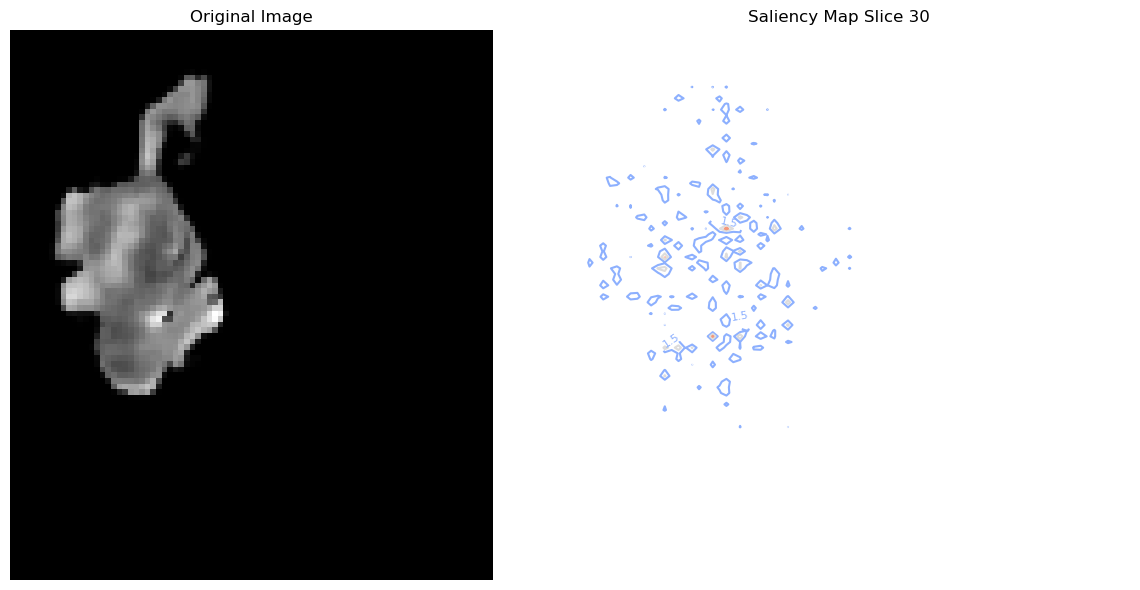

In [21]:
# Visualize a slice of the saliency map (for example, slice index 30)
batch = next(iter(val_loader))
input_image = batch['image']
input_image = input_image[image_number].unsqueeze(0)

visualize_saliency(saliency_map, input_image.flip(3) , slice_idx=30)

In [ ]:
def create_segmentation_mask(image, threshold=0.1):
    """
    Create a binary segmentation mask for the image based on a threshold.
    
    Args:
        image (numpy.array or torch.Tensor): The input image to segment.
        threshold (float): The intensity threshold to classify pixels as part of the region of interest.
    
    Returns:
        mask (numpy.array or torch.Tensor): The binary segmentation mask.
    """
    # Convert to numpy array if it's a tensor
    if isinstance(image, torch.Tensor):
        image = image.cpu().detach().numpy()

    # Thresholding to create a binary mask (white blobs will be selected)
    mask = image > threshold
    
    # Optionally, apply morphological operations to refine the mask
    # For example, filling holes and removing small areas:
    labeled_mask = measure.label(mask, connectivity=2)  # Label connected components
    mask = labeled_mask > 0  # Remove small disconnected regions

    return torch.tensor(mask, dtype=torch.float32)




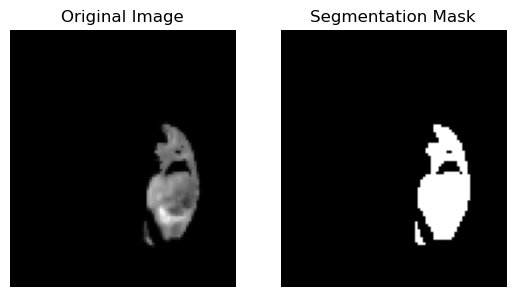

In [ ]:
# Create the segmentation mask
slice_index = 30

# Detach the input_image from the computation graph, move to CPU, and convert to NumPy
original_image_np = input_image.detach().cpu().numpy()

# Get the slice of the image
original_image_slice = original_image_np[0, 0, slice_index, :, :]  # [batch, channel, depth, height, width]

# Create the segmentation mask from the image slice
segmentation_mask = create_segmentation_mask(original_image_slice)

# Visualize the segmentation mask alongside the original image
plt.subplot(1, 2, 1)
plt.imshow(original_image_slice, cmap='gray')  # Show the original image slice
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmentation_mask, cmap='gray')  # Show the segmentation mask
plt.title('Segmentation Mask')
plt.axis('off')

plt.show()


In [ ]:
def weighted_mse_loss(outputs, targets, weights):
    """
    Computes the weighted MSE loss where the weights are applied to each element.
    """
    # Ensure outputs and targets have the same size
    assert outputs.size() == targets.size(), "Outputs and targets must have the same shape."

    # Compute the squared error
    mse_loss = (outputs - targets) ** 2

    # Apply the weights (using broadcasting for the per-feature loss)
    weighted_mse_loss = mse_loss * weights

    # Return the average weighted MSE loss
    return weighted_mse_loss.mean()

def evaluate_model(model, test_loader, device, shapley_values_scaled_tensor):
    model.eval()  # Set model to evaluation mode

    # Initialize metrics
    mse_metric = MeanSquaredError()
    r2_metric = R2Score()

    total_loss = 0.0
    total_samples = 0
    all_outputs = []
    all_labels = []

    # Ensure that the weights are on the same device as the model
    shapley_values_scaled_tensor = shapley_values_scaled_tensor.to(device)

    with torch.no_grad():
        for batch in test_loader:
            inputs = batch['image'].to(device)
            targets = batch['label'].to(device)

            # Forward pass
            outputs = model(inputs)

            # Flatten the outputs and targets for weighted MSE computation
            outputs_flat = outputs.view(-1)
            targets_flat = targets.view(-1)

            # Calculate weighted MSE loss using the SHAP values as weights
            # Here, assuming the SHAP values are the same for all samples in the batch
            weights = shapley_values_scaled_tensor.repeat(outputs_flat.size(0), 1).view(-1)  # Repeat weights across all samples
            loss = weighted_mse_loss(outputs_flat, targets_flat, weights)

            print(f"The loss for this image is {loss.item()}")

            # Update total loss and total samples
            total_loss += loss.item() * inputs.size(0)
            total_samples += inputs.size(0)

            # Collect outputs and labels for metric computation
            all_outputs.append(outputs)
            all_labels.append(targets)

    # Concatenate all outputs and labels across the batches
    all_outputs = torch.cat(all_outputs, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    # Flatten the outputs and labels for metric computation (i.e., flatten into a 1D tensor)
    all_outputs = all_outputs.view(-1)  # Flatten to 1D tensor
    all_labels = all_labels.view(-1)    # Flatten to 1D tensor

    # Calculate metrics using torchmetrics
    mse = mse_metric(all_outputs, all_labels)
    r2 = r2_metric(all_outputs, all_labels)

    avg_loss = total_loss / total_samples  # Average loss over the dataset

    print(f"Test Loss: {avg_loss:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"R2 Score: {r2:.4f}")

    return avg_loss, mse, r2, all_outputs, all_labels

In [ ]:
epoch=14
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet3DRegression(in_channels=1, out_channels=out_shape,weights=shapley_values_scaled_tensor).to(device)  
model = load_model(model, data_path+f"DTI_feat_{epoch}.pth")

# Evaluate the model on test data
# avg_loss, mse, r2, all_outputs, all_labels=evaluate_model(model, test_loader, device, weights=shapley_values_scaled_tensor)

TypeError: UNet3DRegression.__init__() missing 1 required positional argument: 'weights'

In [ ]:
class UNet3DRegression_survival(nn.Module):
    def __init__(self, in_channels, out_channels, feature_importances=None, l1_lambda=1e-5):
        super(UNet3DRegression_survival, self).__init__()

        # Initialize UNet with 3D structure
        self.unet = UNet(
            spatial_dims=3,
            in_channels=in_channels,
            out_channels=out_channels,
            channels=(16, 32, 64, 128),
            strides=(2, 2, 2),
            kernel_size=3,
            up_kernel_size=3,
            num_res_units=2,
            act='PReLU',
            norm='INSTANCE',
            dropout=0.1,
        )

        # Initialize regression layer as None initially
        self.regression_layer = None
        self.feature_importances = feature_importances  # Holds feature importance for scaling weights
        self.l1_lambda = l1_lambda  # L1 regularization strength

        # Add layers for survival prediction
        self.fc1 = nn.Linear(55, 128).to(device)  # First fully connected layer
        self.fc2 = nn.Linear(128, 64).to(device)    # Final output for survival prediction
        self.fc3 = nn.Linear(64, 32).to(device) 
        self.fc4 = nn.Linear(32, 1).to(device) 

    def forward(self, x):
        # Check for 5D input shape (batch_size, channels, depth, height, width)
        if x.ndimension() == 4:  # Shape: (channels, depth, height, width)
            x = x.unsqueeze(0)

        _, _, depth, height, width = x.size()

        # Resize input dimensions if necessary
        if depth % 16 != 0 or height % 16 != 0 or width % 16 != 0:
            new_depth = (depth // 16 + 1) * 16
            new_height = (height // 16 + 1) * 16
            new_width = (width // 16 + 1) * 16
            x = F.interpolate(x, size=(new_depth, new_height, new_width), mode='trilinear', align_corners=True)

        # Apply the U-Net
        x = self.unet(x)

        # Flatten the output for the regression layer
        flattened_size = x.numel() // x.size(0)
        if self.regression_layer is None:
            self.regression_layer = nn.Linear(flattened_size, 55).to(device)   # Adjust output size to 55 parameters

        x = x.view(x.size(0), -1)  # Flatten the output
        x = self.regression_layer(x)  # Regression output (55 parameters)

        # Apply feature importance weighting if available
        if self.feature_importances is not None:
            x = x * self.feature_importances  # Element-wise multiplication with feature importance

        # Pass through fully connected layers for survival prediction
        x = F.relu(self.fc1(x))  # First fully connected layer
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)  # Final output layer (single value for survival)

        return x

    def l1_regularization(self):
        """
        Computes L1 regularization (penalty) on the model parameters.
        """
        l1_norm = 0.0
        for param in self.parameters():
            l1_norm += torch.sum(torch.abs(param))
        return self.l1_lambda * l1_norm  # L1 penalty term scaled by lambda


In [ ]:
seeds = [21, 22, 23, 24, 25, 26, 27, 28, 29, 30] 
optimizer = torch.optim.Adam([
    {'params': model.unet.parameters(), 'weight_decay': 0.0},  # No L2 regularization for UNet layers
    {'params': model.regression_layer.parameters(), 'weight_decay': 1e-4},  # L2 regularization for regression layer
    {'params': model.fc1.parameters(), 'weight_decay': 1e-4},  # L2 regularization for fc1
    {'params': model.fc2.parameters(), 'weight_decay': 1e-4},  # L2 regularization for fc2
    {'params': model.fc3.parameters(), 'weight_decay': 1e-4},  # L2 regularization for fc3
    {'params': model.fc4.parameters(), 'weight_decay': 1e-4},  # L2 regularization for fc4
], lr=1e-4)

model = UNet3DRegression_survival(in_channels=1, out_channels=out_shape, feature_importances=shapley_values_scaled_tensor).to(device) 
model = load_model(model, data_path+f"model_epoch_{epoch+1}.pth")

/tmp/ipykernel_4031704/275552138.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path)


In [ ]:
class AttentionFusion(nn.Module):
    def __init__(self, input_size):
        super(AttentionFusion, self).__init__()
        # Learnable attention weights for each modality
        self.attention_fc = nn.Linear(input_size, 1)  # Scalar weight per modality

    def forward(self, x1, x2):
        """
        Forward pass for attention-based fusion.
        x1: Output of the first model (e.g., MRI)
        x2: Output of the second model (e.g., CT)
        """
        # Calculate attention weights for each modality (scalar weight)
        att1 = torch.sigmoid(self.attention_fc(x1))  # Attention weight for modality 1
        att2 = torch.sigmoid(self.attention_fc(x2))  # Attention weight for modality 2

        # Perform weighted fusion of the two modality outputs
        fused_output = att1 * x1 + att2 * x2

        return fused_output
    
class MultiModalUNet3DWithAttention(nn.Module):
    def __init__(self, model_1, model_2, fusion_size=128):
        super(MultiModalUNet3DWithAttention, self).__init__()

        # Two separate models for different modalities
        self.model_1 = model_1  # Model for modality 1
        self.model_2 = model_2  # Model for modality 2

        # Fully connected layers for final survival prediction
        self.fc1 = nn.Linear(1, fusion_size)
        self.fc2 = nn.Linear(fusion_size, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)

    def forward(self, x1, x2):
        # Process the first modality through the first model
        output_1 = self.model_1(x1)
        output_2 = self.model_2(x2)
        output_size = output_1.size(1)
        self.attention_fusion = AttentionFusion(input_size=output_size)
        fused_output = self.attention_fusion(output_1, output_2)

        # Pass through fully connected layers for final prediction
        x = F.relu(self.fc1(fused_output))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x) 
        return x


In [ ]:
def create_3d_cnn_with_regression(output_size):
    # Define the input layer with shape (depth, height, width, channels)
    input_layer = layers.Input(shape=(10, 64, 64, 1))  # (depth, height, width, channels)

    # 3D convolutional layers
    x = layers.Conv3D(32, (3, 3, 3), activation='relu', padding='same')(input_layer)
    x = layers.MaxPooling3D((2, 2, 2))(x)  # Pooling over the 3D space

    x = layers.Conv3D(64, (3, 3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling3D((2, 2, 2))(x)

    x = layers.Conv3D(128, (3, 3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling3D((2, 2, 2))(x)

    # Flatten the output for the dense layer
    x = layers.Flatten()(x)

    # Dense layer (optional, can be adjusted as needed)
    x = layers.Dense(256, activation='relu')(x)

    # Output layer for regression (e.g., predicting continuous values)
    output_layer = layers.Dense(output_size)(x)  # output_size can vary (e.g., 1 for a single output, or more)

    # Create and compile the model
    model = models.Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

    return model




In [ ]:

checkpoint_files = [f for f in os.listdir(data_path) if 'DTI_feat_' in f and f.endswith('.pth')]

# Initialize an empty list to store the data
data = []

# Iterate over each checkpoint file
for checkpoint_file in checkpoint_files:
    # Construct the full path to the checkpoint file
    checkpoint_path = os.path.join(data_path, checkpoint_file)
    
    # Load the checkpoint
    checkpoint = torch.load(checkpoint_path)
    
    # Extract the required values (train_loss and val_loss)
    epoch = checkpoint.get('epoch', None)  # Use 'latest' for the latest checkpoint
    loss = checkpoint.get('train_loss', None)
    val_loss = checkpoint.get('val_loss', None)

    if isinstance(train_loss, torch.Tensor):
        train_loss = train_loss.item()
    
    
    # Store the extracted information in the data list
    data.append({
        'epoch': epoch,
        'train_loss': loss,
        'val_loss': val_loss,
        'checkpoint_path': checkpoint_path
    })

# Convert the list of dictionaries into a pandas DataFrame
df = pd.DataFrame(data)

# Sort by epoch (if necessary)
df['epoch'] = pd.to_numeric(df['epoch'], errors='coerce')  # Ensure 'epoch' is numeric, convert 'latest' to NaN
df = df.sort_values(by='epoch')  # Sort by epoch number

# Display the resulting DataFrame
# print(df)


NameError: name 'os' is not defined